Using device: cpu
Loaded ONE long trajectory: T=152500, d=3
TTT (H=10) | K=10 | Epoch 01 | train_MSE=15.352274 | val_MSE=14.276445 | val_MAE=2.876932 | best_val_MSE=14.276445
TTT (H=10) | K=10 | Epoch 02 | train_MSE=6.865287 | val_MSE=7.420666 | val_MAE=2.061361 | best_val_MSE=7.420666
TTT (H=10) | K=10 | Epoch 03 | train_MSE=3.454364 | val_MSE=3.524803 | val_MAE=1.392858 | best_val_MSE=3.524803
TTT (H=10) | K=10 | Epoch 04 | train_MSE=1.550901 | val_MSE=1.541684 | val_MAE=0.878134 | best_val_MSE=1.541684
TTT (H=10) | K=10 | Epoch 05 | train_MSE=0.684752 | val_MSE=0.692436 | val_MAE=0.549602 | best_val_MSE=0.692436
TTT (H=10) | K=10 | Epoch 06 | train_MSE=0.313602 | val_MSE=0.321242 | val_MAE=0.342096 | best_val_MSE=0.321242
TTT (H=10) | K=10 | Epoch 07 | train_MSE=0.152142 | val_MSE=0.165801 | val_MAE=0.228556 | best_val_MSE=0.165801
TTT (H=10) | K=10 | Epoch 08 | train_MSE=0.084442 | val_MSE=0.097405 | val_MAE=0.167032 | best_val_MSE=0.097405
TTT (H=10) | K=10 | Epoch 09 | train_MSE=

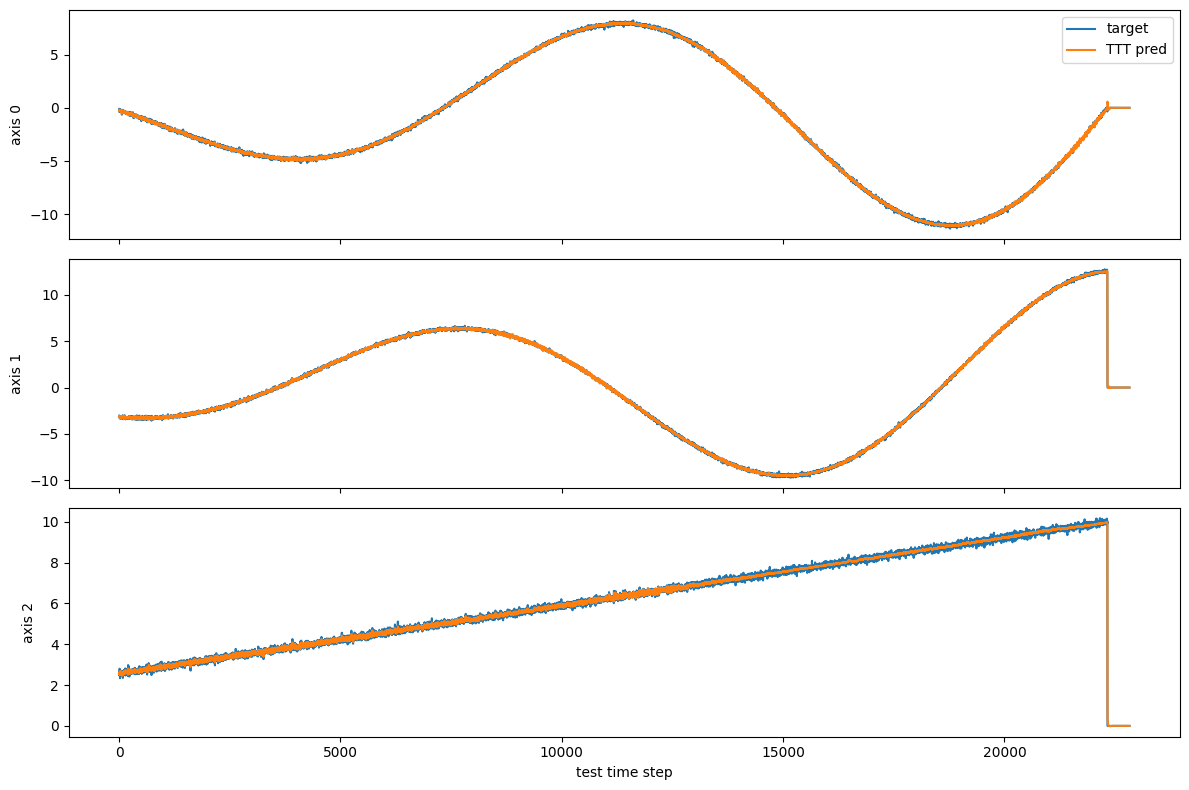

In [1]:
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

csv_path = '../../robotic_arm_dataset_multiple_trajectories.csv'
df = pd.read_csv(csv_path)
data = torch.from_numpy(df[['Axis_0_Angle', 'Axis_1_Angle', 'Axis_2_Angle']].values.astype(np.float32))
T, d = data.shape
print(f'Loaded ONE long trajectory: T={T}, d={d}')

def make_splits(series, train_frac=0.7, val_frac=0.15):
    T = len(series)
    train_end = int(train_frac * T)
    val_end = int((train_frac + val_frac) * T)
    train = series[:train_end]
    val = series[train_end:val_end]
    test = series[val_end:]
    return train, val, test

train_series, val_series, test_series = make_splits(data)


class SlidingWindowDataset(Dataset):
    def __init__(self, series, K):
        self.series = series
        self.K = K

    def __len__(self):
        return len(self.series) - self.K

    def __getitem__(self, idx):
        x = self.series[idx:idx + self.K]
        y = self.series[idx + self.K]
        return x, y


class RNNRegressor(nn.Module):
    def __init__(self, d_in, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(d_in, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, d_in)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        n += batch_size
    return total_loss / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        n += batch_size
    return total_loss / n


import copy

def evaluate_with_ttt(base_model, test_series, K, device, adapt_lr=1e-4, adapt_steps=1):
    model = copy.deepcopy(base_model).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=adapt_lr)
    criterion = nn.MSELoss()
    model.train()
    T_test = len(test_series)
    preds = []
    targets = []
    total_loss = 0.0
    n = 0
    for start in range(T_test - K):
        window = test_series[start:start + K].unsqueeze(0).to(device)
        target = test_series[start + K].unsqueeze(0).to(device)
        for _ in range(adapt_steps):
            optimizer.zero_grad()
            pred = model(window)
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            pred = model(window)
            loss = criterion(pred, target)
        preds.append(pred.squeeze(0).cpu().numpy())
        targets.append(target.squeeze(0).cpu().numpy())
        total_loss += loss.item()
        n += 1
    preds = np.stack(preds)
    targets = np.stack(targets)
    # compute metrics from full sequences
    mse = ((preds - targets) ** 2).mean()
    mae = np.abs(preds - targets).mean()
    return preds, targets, mse, mae


# K as in the original TTT notebook, but hidden size H is fixed to 10
Ks = [10, 50, 100]
H = 10
num_epochs = 20
batch_size = 256
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss()
results = {}

for K in Ks:
    train_ds = SlidingWindowDataset(train_series, K)
    val_ds = SlidingWindowDataset(val_series, K)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = RNNRegressor(d_in=d, hidden_size=H).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_val = float('inf')
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_mse = train_one_epoch(model, train_loader, optimizer, criterion_mse, device)
        val_mse = eval_epoch(model, val_loader, criterion_mse, device)
        val_mae = eval_epoch(model, val_loader, criterion_mae, device)
        if val_mse < best_val:
            best_val = val_mse
            best_state = copy.deepcopy(model.state_dict())
        print(f'TTT (H={H}) | K={K} | Epoch {epoch:02d} | train_MSE={train_mse:.6f} | val_MSE={val_mse:.6f} | val_MAE={val_mae:.6f} | best_val_MSE={best_val:.6f}')

    model.load_state_dict(best_state)
    base_test_ds = SlidingWindowDataset(test_series, K)
    base_test_loader = DataLoader(base_test_ds, batch_size=batch_size, shuffle=False)
    base_test_mse = eval_epoch(model, base_test_loader, criterion_mse, device)
    base_test_mae = eval_epoch(model, base_test_loader, criterion_mae, device)
    preds_ttt, targets_ttt, ttt_mse, ttt_mae = evaluate_with_ttt(model, test_series, K, device, adapt_lr=1e-4, adapt_steps=1)
    results[K] = {
        'model': model,
        'base_test_mse': base_test_mse,
        'base_test_mae': base_test_mae,
        'ttt_mse': ttt_mse,
        'ttt_mae': ttt_mae,
        'preds_ttt': preds_ttt,
        'targets_ttt': targets_ttt,
    }
    print(f'(H={H}) K={K} | base test MSE={base_test_mse:.6f} | base test MAE={base_test_mae:.6f} | TTT test MSE={ttt_mse:.6f} | TTT test MAE={ttt_mae:.6f}')


K_plot = 50
preds = results[K_plot]['preds_ttt']
targets = results[K_plot]['targets_ttt']
t = np.arange(len(preds))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, targets[:, i], label='target')
    ax.plot(t, preds[:, i], label='TTT pred')
    ax.set_ylabel(f'axis {i}')
axes[-1].set_xlabel('test time step')
axes[0].legend()
plt.tight_layout()
plt.show()
